In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [ ]:
# Create folders if not present
os.makedirs("models", exist_ok=True)
os.makedirs("images", exist_ok=True)

In [ ]:

df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,2,124,390,0,0,154,1,5.3,1,1,3,1
1,57,0,3,103,333,0,1,133,0,0.7,0,2,2,0
2,43,1,2,153,229,0,0,184,0,1.1,0,0,1,0
3,71,1,1,98,302,0,1,93,1,0.7,1,0,2,1
4,36,0,0,124,379,0,1,134,1,1.0,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,71,1,1,150,216,0,2,82,1,2.3,2,2,3,1
14996,64,0,2,129,410,0,1,70,0,0.4,2,0,1,0
14997,42,1,2,143,212,0,1,108,1,2.7,2,0,1,0
14998,46,0,3,155,279,0,0,202,0,0.9,0,0,2,1


## 1. age

2. sex

3. chest pain type (4 values)

4. resting blood pressure

5. serum cholestoral in mg/dl

6. fasting blood sugar > 120 mg/dl

7. resting electrocardiographic results (values 0,1,2)

8. maximum heart rate achieved

9. exercise induced angina

10. oldpeak = ST depression induced by exercise relative to rest ##

In [ ]:
df.shape

(15000, 14)

In [ ]:
# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Gradient Boosting Model
gb = GradientBoostingClassifier(random_state=42)

# Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Training Model...")

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters")
print(grid.best_params_)


Training Model...

Best Parameters
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
# Prediction

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy: 72.1 %

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1588
           1       0.71      0.68      0.70      1412

    accuracy                           0.72      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.72      0.72      0.72      3000



In [ ]:
joblib.dump(best_model, "models/heart_model.pkl")

['models/heart_model.pkl']

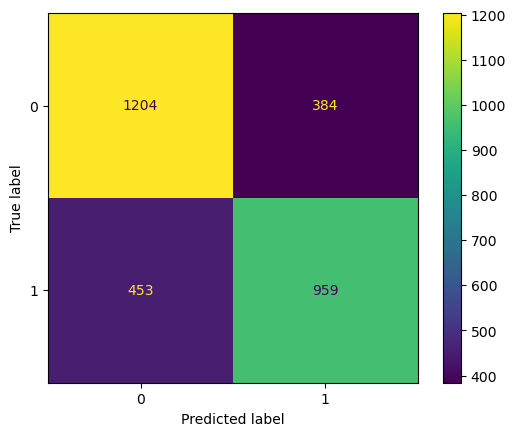

In [ ]:
# Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred)
)

disp.plot()

plt.savefig("images/confusion_matrix.png")

plt.show()

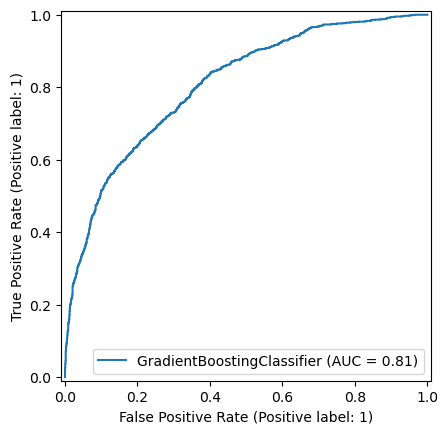

In [ ]:
# ROC Curve

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.savefig("images/roc_curve.png")
plt.show()

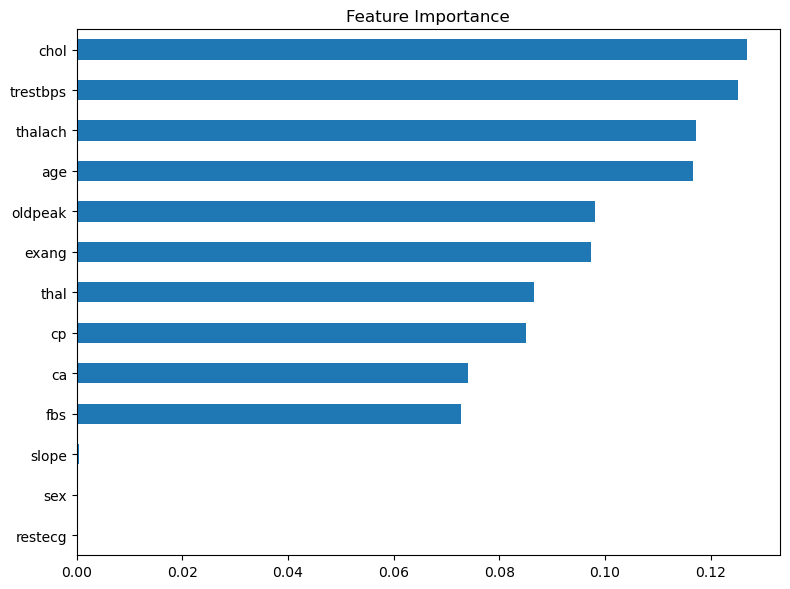

In [ ]:
# Feature Importance

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind="barh")

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("images/feature_importance.png")

plt.show()